In [1]:
import numpy as np

Rax, Zax = 1.0, 0.0
Rell, Zell = 0.3, 0.5
phi0 = 0.0

BPhiax = 2.5

m = 3 # toroidal turn number
n = 1
iota = float(n)/float(m)

def cycleRZ(phi):
    return np.array([
        Rell * np.cos(iota*phi+phi0) + Rax,
        Zell * np.sin(iota*phi+phi0) + Zax
    ])

dTETdphi = 1./3.
def TETu(phi):
    return phi/3 + np.pi/2 + np.pi/9
def TETs(phi):
    return phi/3 + np.pi/2 - np.pi/9

lamu = np.e**(1/5)
lams = np.e**(-1/5)

def BR0BZ0(phi):
    Rc = cycleRZ(phi)[0]
    BR0 = - iota * Rell * np.sin(iota*phi+phi0)      /Rc*BPhi(phi, cycleRZ(phi))
    BZ0 = + iota * Zell * np.cos(iota*phi+phi0)      /Rc*BPhi(phi, cycleRZ(phi))
    return np.array([BR0, BZ0])
def BRBZ(phi, X_pol):
    
    V = np.array([
        [np.cos(TETu(phi) ), np.cos(TETs(phi) )],
        [np.sin(TETu(phi) ), np.sin(TETs(phi) )],
    ])
    Lam = np.array([
        [np.log( np.abs(lamu) )/(2*m*np.pi), 0],
        [0, np.log( np.abs(lams) )/(2*m*np.pi)],
    ])
    
    A = V @ Lam @ np.linalg.inv(V) + np.array([
        [0.0, -dTETdphi],
        [dTETdphi, 0.0],
    ]) 
    A[:,0]-= 2 * BR0BZ0(phi) / BPhi(phi, cycleRZ(phi) )
    Rc = cycleRZ(phi)[0]
    return BR0BZ0(phi)  +  BPhi(phi, cycleRZ(phi) ) /Rc * A @ (X_pol-cycleRZ(phi))

def BPhi(phi, X_pol):
    return Rax * BPhiax / X_pol[0]
def frac_RBpol_BPhi(phi, X_pol):
    return X_pol[0] * BRBZ(phi, X_pol) / BPhi(phi, X_pol)

def dRBpol_BPhi_dRZ(phi):
    V = np.array([
        [np.cos(TETu(phi) ), np.cos(TETs(phi) )],
        [np.sin(TETu(phi) ), np.sin(TETs(phi) )],
    ])
    Lam = np.array([
        [np.log( np.abs(lamu) )/(2*m*np.pi), 0],
        [0, np.log( np.abs(lams) )/(2*m*np.pi)],
    ])
    
    A = V @ Lam @ np.linalg.inv(V) + np.array([
        [0.0, -dTETdphi],
        [dTETdphi, 0.0],
    ]) 
    return A

In [2]:
from scipy.integrate import solve_ivp
DXpol_ivp = solve_ivp(lambda phi, DXpol: (dRBpol_BPhi_dRZ(phi) @ DXpol.reshape(2,2) ).flatten(), [0, 2*m*np.pi], np.array([[1.0, 0.0], [0.0, 1.0]]).flatten(), dense_output=True, max_step=2*np.pi/1000)
DPm_ivp = solve_ivp(lambda phi, DPm: (
    dRBpol_BPhi_dRZ(phi) @ DPm.reshape(2,2)
-   DPm.reshape(2,2) @ dRBpol_BPhi_dRZ(phi) 
).flatten(), [0, 2*m*np.pi], DXpol_ivp.sol(2*m*np.pi), dense_output=True, max_step=2*np.pi/1000)


In [ ]:
from plotly.graph_objs import Scatter3d
from plotly.subplots import make_subplots
import numpy as np

import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{'is_3d': True}, ]],
)

nPhi, nS = 400, 40
# Phi = np.linspace(0.0, 2*3*np.pi - 2./3*np.pi , num=nPhi, endpoint=True)
Phi = np.linspace(0.0, 2*3*np.pi, num=nPhi, endpoint=True)
TETu = + Phi/3 + np.pi/2 + np.pi/9
TETs = + Phi/3 + np.pi/2 - np.pi/9

Rax, Zax = 1.0, 0.0
Rell, Zell = 0.3, 0.5
iota = 1./3.
phi0 = 0.0
Rc = Rell * np.cos(iota*Phi+phi0) + Rax
Zc = Zell * np.sin(iota*Phi+phi0) + Zax



## The four branches of the invariant manifolds

R_isphi = Rc + np.linspace(0.0, 0.1, num=nS)[:,None] * np.cos(TETs)[None,:] # [iS, iPhi]
Z_isphi = Zc + np.linspace(0.0, 0.1, num=nS)[:,None] * np.sin(TETs)[None,:] # [iS, iPhi]
S_isphi = np.linspace(0.0, 0.1, num=nS)[:,None] * np.ones_like(TETs)[None,:] # [iS, iPhi]
x_isphi = R_isphi*np.cos(Phi)[None,:]
y_isphi = R_isphi*np.sin(Phi)[None,:] 
z_isphi = Z_isphi

fig.add_trace(
    go.Surface(
        x=x_isphi,
        y=y_isphi, 
        z=z_isphi,
        surfacecolor=S_isphi, 
        colorscale="Blues_r",
#         opacityscale=[
#             [0.0, 0.3], # vertex with min value is totally opaque  
# #             [0.1, 0.9],
# #             [0.2, 0.7],
#             [0.5, 0.8],
#             [1.0, 0.0] # vertex with max value is totally transparent  
#         ],
    ),1,1, )

R_isphi = Rc + np.linspace(0.0, 0.1, num=nS)[:,None] * np.cos(TETu)[None,:] # [iS, iPhi]
Z_isphi = Zc + np.linspace(0.0, 0.1, num=nS)[:,None] * np.sin(TETu)[None,:] # [iS, iPhi]
S_isphi = np.linspace(0.0, 0.1, num=nS)[:,None] * np.ones_like(TETu)[None,:] # [iS, iPhi]
x_isphi = R_isphi*np.cos(Phi)[None,:]
y_isphi = R_isphi*np.sin(Phi)[None,:] 
z_isphi = Z_isphi

fig.add_trace(
    go.Surface(
        x=x_isphi,
        y=y_isphi,
        z=z_isphi,
        surfacecolor=S_isphi, 
        colorscale="Oranges_r",
#         opacityscale=[
#             [0.0, 0.3], # vertex with min value is totally opaque  
# #             [0.1, 0.9],
# #             [0.2, 0.7],
#             [0.5, 0.8],
#             [1.0, 0.0] # vertex with max value is totally transparent  mhdpy.visual.axisym 
#         ],
    ),1,1, )

R_isphi = Rc - np.linspace(0.0, 0.1, num=nS)[:,None] * np.cos(TETs)[None,:] # [iS, iPhi]
Z_isphi = Zc - np.linspace(0.0, 0.1, num=nS)[:,None] * np.sin(TETs)[None,:] # [iS, iPhi]
S_isphi = np.linspace(0.0, 0.1, num=nS)[:,None] * np.ones_like(TETs)[None,:] # [iS, iPhi]
x_isphi = R_isphi*np.cos(Phi)[None,:]
y_isphi = R_isphi*np.sin(Phi)[None,:] 
z_isphi = Z_isphi

fig.add_trace(
    go.Surface(
        x=x_isphi,
        y=y_isphi,
        z=z_isphi,
        surfacecolor=S_isphi, 
        colorscale="Blues_r",
#         opacityscale=[
#             [0.0, 0.3], # vertex with min value is totally opaque  
# #             [0.1, 0.9],
# #             [0.2, 0.7],
#             [0.5, 0.8],
#             [1.0, 0.0] # vertex with max value is totally transparent  
#         ],
    ),1,1, )

R_isphi = Rc - np.linspace(0.0, 0.1, num=nS)[:,None] * np.cos(TETu)[None,:] # [iS, iPhi]
Z_isphi = Zc - np.linspace(0.0, 0.1, num=nS)[:,None] * np.sin(TETu)[None,:] # [iS, iPhi]
S_isphi = np.linspace(0.0, 0.1, num=nS)[:,None] * np.ones_like(TETu)[None,:] # [iS, iPhi]
x_isphi = R_isphi*np.cos(Phi)[None,:]
y_isphi = R_isphi*np.sin(Phi)[None,:] 
z_isphi = Z_isphi

fig.add_trace(
    go.Surface(
        x=x_isphi,
        y=y_isphi,
        z=z_isphi,
        surfacecolor=S_isphi, 
        colorscale="Oranges_r",
#         opacityscale=[
#             [0.0, 0.3], # vertex with min value is totally opaque  
# #             [0.1, 0.9],
# #             [0.2, 0.7],
#             [0.5, 0.8],
#             [1.0, 0.0] # vertex with max value is totally transparent  
#         ],
    ),1,1, )


# Cycle trace
# fig.add_trace(    
#     go.Scatter3d(
#         x=Rc*np.cos(Phi), 
#         y=Rc*np.sin(Phi), 
#         z=Zc, mode="lines", line=dict(color='black', width=3) ),               
# )

# # FLT trajectory
# fig.add_trace(    
#     go.Scatter3d(
#         x=cylflt.sol(Phi*9)[0,:]*np.cos(Phi*9), 
#         y=cylflt.sol(Phi*9)[0,:]*np.sin(Phi*9), 
#         z=cylflt.sol(Phi*9)[1,:], mode="lines", line=dict(color='black', width=3) ),               
# )





# Reference transparent torus
torus_nPhi = 60
torus_Phi = np.linspace(0.0, 2*np.pi*(2./3.), num=torus_nPhi, endpoint=True)

torus_Rc = Rell * np.cos(iota* np.linspace(0.0, 2*3*np.pi) + phi0) + Rax
torus_Zc = Zell * np.sin(iota* np.linspace(0.0, 2*3*np.pi) + phi0) + Zax

x_isphi = torus_Rc[:,None] * np.cos(torus_Phi)[None,:]
y_isphi = torus_Rc[:,None] * np.sin(torus_Phi)[None,:] 
z_isphi = torus_Zc[:,None] * np.ones_like(torus_Phi)[None,:]

fig.add_trace(
    go.Surface(
        x=x_isphi,
        y=y_isphi,
        z=z_isphi,
        surfacecolor=np.abs(z_isphi),
        colorscale="greys", 
#         colorscale="Oranges_r",
#         opacityscale=[
#             [0.0, 0.8], # vertex with min value is totally opaque  
# #             [0.1, 0.9],
# #             [0.2, 0.7],
#             [0.5, 0.8],
#             [1.0, 0.0] # vertex with max value is totally transparent  
#         ],
        opacity=0.20,
    ),1,1, )




def draw_eigvec_at_Phi(fig, Phi, DPm_ivp,arrowlen=10e-2):
    import numpy.linalg as LA
    eigvals, eigvecs = LA.eig(
        np.moveaxis(DPm_ivp.sol(Phi).reshape((2,2,-1)), 2, 0)
    )
    # Exchange eigenvectors such that 
    #   eigvals[:,0] in [0,1], 
    #   eigvals[:,1] in [0,+\infinity)
    for i in range(len(Phi)):
        if eigvals[i,0] > 1.0:
#             temp = np.copy( eigvecs[i,0,:] )
            eigvecs[i,:,[0,1]] = eigvecs[i,:,[1,0]]
    
    cycleRZs = np.asarray([cycleRZ(phi) for phi in Phi])
    Rc, Zc = cycleRZs[:,0], cycleRZs[:,1]
    
    
    for i in range(len(Phi)):
        circTET = np.linspace(0.0, 2*np.pi)
        circR = Rc[i] + arrowlen * np.cos(circTET)
        circZ = Zc[i] + arrowlen * np.sin(circTET)
        fig.add_trace(    
            go.Scatter3d(
                x=circR * np.cos(Phi[i]), 
                y=circR * np.sin(Phi[i]), 
                z=circZ, mode="lines", line=dict(color='grey', width=2) ),               
        )
        
    Rend = Rc + arrowlen * eigvecs[:,0,0]
    Zend = Zc + arrowlen * eigvecs[:,1,0]
    fig.add_trace(    
        go.Cone(
            x=Rend*np.cos(Phi), #[Rc*np.cos(phi), Rend*np.cos(phi)], 
            y=Rend*np.sin(Phi), #[Rc*np.sin(phi), Rend*np.sin(phi)], 
            z=Zend, #[Zc, Zend],
            u=+Rc*np.cos(Phi) - Rend*np.cos(Phi), 
            v=+Rc*np.sin(Phi) - Rend*np.sin(Phi), 
            w=+Zc -Zend, 
            cauto=False, cmin= 0.0e-2, cmax= 5e-2,
#             lighting_ambient=0.8,
            sizemode="absolute",
            sizeref=4e-2,
            colorscale="Blues",
        ),               
    )
    Rend = Rc - arrowlen * eigvecs[:,0,0]
    Zend = Zc - arrowlen * eigvecs[:,1,0]
    fig.add_trace(    
        go.Cone(
            x=Rend*np.cos(Phi), #[Rc*np.cos(phi), Rend*np.cos(phi)], 
            y=Rend*np.sin(Phi), #[Rc*np.sin(phi), Rend*np.sin(phi)], 
            z=Zend, #[Zc, Zend],
            u=+Rc*np.cos(Phi) - Rend*np.cos(Phi), 
            v=+Rc*np.sin(Phi) - Rend*np.sin(Phi), 
            w=+Zc -Zend, 
            cauto=False, cmin= 0.0e-2, cmax= 5e-2,
#             lighting_ambient=0.8,
            sizemode="absolute",
            sizeref=4e-2,
            colorscale="Blues",
        ),               
    )
    Rend = Rc + arrowlen * eigvecs[:,0,1]
    Zend = Zc + arrowlen * eigvecs[:,1,1]
    fig.add_trace(    
        go.Cone(
            x=Rend*np.cos(Phi), #[Rc*np.cos(phi), Rend*np.cos(phi)], 
            y=Rend*np.sin(Phi), #[Rc*np.sin(phi), Rend*np.sin(phi)], 
            z=Zend, #[Zc, Zend],
            u=-Rc*np.cos(Phi) + Rend*np.cos(Phi), 
            v=-Rc*np.sin(Phi) + Rend*np.sin(Phi), 
            w=-Zc +Zend, 
            cauto=False, cmin= 0.0e-2, cmax= 10e-2,
#             lighting_ambient=0.8, 
            sizemode="absolute",
            sizeref=4e-2,
            colorscale="Reds",
        ),               
    )
    Rend = Rc - arrowlen * eigvecs[:,0,1]
    Zend = Zc - arrowlen * eigvecs[:,1,1]
    fig.add_trace(    
        go.Cone(
            x=Rend*np.cos(Phi), #[Rc*np.cos(phi), Rend*np.cos(phi)], 
            y=Rend*np.sin(Phi), #[Rc*np.sin(phi), Rend*np.sin(phi)], 
            z=Zend, #[Zc, Zend],
            u=-Rc*np.cos(Phi) + Rend*np.cos(Phi), 
            v=-Rc*np.sin(Phi) + Rend*np.sin(Phi), 
            w=-Zc +Zend, 
            cauto=False, cmin= 0.0e-2, cmax= 10e-2,
#             lighting_ambient=0.8,
            sizemode="absolute",
            sizeref=4e-2,
            colorscale="Reds",),               
    )
    


            
            


draw_eigvec_at_Phi(fig, np.linspace(0.0, 2*m*np.pi, num=50), DPm_ivp,)
# draw_eigvec_at_Phi(fig, np.linspace(0.0, 2*m*np.pi - 2.0/3*np.pi, num=50), DPm_ivp,)

cycleRZs = np.asarray( [cycleRZ(phi) for phi in Phi] )
fig.add_trace(    
    go.Scatter3d(
        x=cycleRZs[:,0]*np.cos(Phi), 
        y=cycleRZs[:,0]*np.sin(Phi), 
        z=cycleRZs[:,1], mode="lines", line=dict(color='green', width=5) ),               
)
            

fig.update_layout(width=2000, height=1200) # in pixel unit
# fig.update_layout(width=4000, height=2800) # in pixel unit
# fig.update_layout(
#     scene=dict(
#         xaxis=dict(
#             tickfont=dict(size=25),  # Specify the desired tick text size
#             title=dict(text='x', font=dict(size=72))  # Specify the desired label size
#         ),
#         yaxis=dict(
#             tickfont=dict(size=25),  # Specify the desired tick text size
#             title=dict(text='y', font=dict(size=72))  # Specify the desired label size
#         ),
#         zaxis=dict(
#             tickfont=dict(size=25),  # Specify the desired tick text size
#             title=dict(text='z', font=dict(size=72))  # Specify the desired label size
#         )
#     )
# )




## Prepare PF coil field

In [3]:
import mhdpy.field.axisym
PF_lenratio = 1.5
PF_coils_TET = 2*np.pi * np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
PF_coils_BR = []
PF_coils_BZ = []
PF_coils_dR = 0.05
PF_coils_dZ = 0.05

In [ ]:
from importlib import reload
reload(mhdpy.visual.axisym )

In [ ]:

import mhdpy.visual.axisym 
for i in range(len(PF_coils_TET)):
    PF_coil_Rc = Rax + Rell * PF_lenratio * np.cos(PF_coils_TET[i])
    PF_coil_Zc = Zax + Zell * PF_lenratio * np.sin(PF_coils_TET[i])
    for trace in mhdpy.visual.axisym.PF_coil_plotly_Mesh3d(PF_coil_Rc, PF_coil_Zc, PF_coils_dR, PF_coils_dZ, pts_nPhi=50, Phi_span=[0.0, 2*np.pi*2/3]):
        if i == 1:
            trace.color = "blue"
        fig.add_trace( trace )
fig.show()

In [4]:
R = np.linspace(Rax-Rell*1.1, Rax+Rell*1.1, num=128)
Z = np.linspace(Zax-Zell*1.1, Zax+Zell*1.1, num=128)

In [6]:
from pathlib import Path
READ_FROM_DATA = True
if READ_FROM_DATA:
    for i in range(len(PF_coils_TET)):
        with np.load( Path("/mnt/D/Repo/FusionData/dummyX") / "PF" / "field_computation" / f'B_PF_PF{i+1}.npz' ) as data:
            PF_coils_BR.append(data["BR"])
            PF_coils_BZ.append(data["BZ"])
else:
    for i in range(len(PF_coils_TET)):
        PF_coil_Rc = Rax + Rell * PF_lenratio * np.cos(PF_coils_TET[i])
        PF_coil_Zc = Zax + Zell * PF_lenratio * np.sin(PF_coils_TET[i])
        print(f"Calculating PF{i+1} field.")
        BR_o, BZ_o = mhdpy.field.axisym.BRBZ_induced_by_thick_finitelen_solenoid_multiprocessing(
            R, Z, 
            PF_coil_Rc, PF_coil_Zc, 
            PF_coils_dR, PF_coils_dZ, turn=1, I=1000) # 1kAt
        PF_coils_BR.append(BR_o)
        PF_coils_BZ.append(BZ_o)
        np.savez( Path("/mnt/D/Repo/FusionData/dummyX") / "PF" / "field_computation" / f'B_PF_PF{i+1}.npz', 
             R=R, Z=Z, BR=BR_o, BZ=BZ_o)

In [13]:
BR_pert = np.zeros((len(R), len(Z)))
BZ_pert = np.zeros((len(R), len(Z)))

In [14]:
BR_pert[:,:] = PF_coils_BR[1]
BZ_pert[:,:] = PF_coils_BZ[1]

In [20]:
from scipy.interpolate import RegularGridInterpolator
BR_pert_interp = RegularGridInterpolator((R, Z), BR_pert)
BZ_pert_interp = RegularGridInterpolator((R, Z), BZ_pert)
_BRBZ_pert_interp = RegularGridInterpolator((R, Z), np.stack([BR_pert, BZ_pert], axis=-1))
def BRBZ_pert_interp(Xpol):
    return _BRBZ_pert_interp(Xpol)[0,:]
def BPhi_pert():
    return 0.0

In [10]:
np.stack([BR_pert, BZ_pert], axis=-1).shape

(128, 128, 2)

In [21]:
from scipy.integrate import solve_ivp
deltaXpol_ivp = solve_ivp(
    lambda phi, deltaXpol: dRBpol_BPhi_dRZ(phi) @ deltaXpol \
    + cycleRZ(phi)[0] / BPhi(phi, cycleRZ(phi)) * BRBZ_pert_interp(cycleRZ(phi)) \
    - cycleRZ(phi)[0] * BPhi_pert() / (BPhi(phi, cycleRZ(phi))**2) * BR0BZ0(phi), 
    [0, 2*m*np.pi], np.array([0.0, 0.0]), dense_output=True, max_step=2*np.pi/1000)
Delta_x0_at_phi_0 = np.linalg.inv( DPm_ivp.sol(0.0).reshape(2,2) - np.identity(2) ) @ (-deltaXpol_ivp.sol(2*m*np.pi) )
Delta_x0_ivp = solve_ivp(lambda phi, Delta_x0:
    dRBpol_BPhi_dRZ(phi) @ Delta_x0 \
    + cycleRZ(phi)[0] / BPhi(phi, cycleRZ(phi)) * BRBZ_pert_interp(cycleRZ(phi)) \
    - cycleRZ(phi)[0] * BPhi_pert() / (BPhi(phi, cycleRZ(phi))**2) * BR0BZ0(phi), 
    [0, 2*m*np.pi], Delta_x0_at_phi_0, dense_output=True, max_step=2*np.pi/1000)


In [ ]:
# np.set_printoptions(threshold=np.inf)
print(Delta_x0_ivp.sol(0.0))

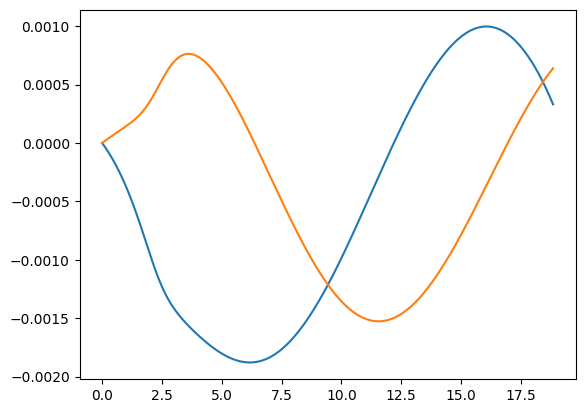

In [22]:
import matplotlib.pyplot as plt
plt.plot(deltaXpol_ivp.t, deltaXpol_ivp.y[0,:], deltaXpol_ivp.t, deltaXpol_ivp.y[1,:])

In [39]:

shift_arrow_ind = 14
shift_arrow_indgap = 30 
deltaXpol_ivp.sol(Phi[0::shift_arrow_indgap])


array([[ 0.00000000e+00, -5.95127849e-04, -1.36318153e-03,
        -1.68916333e-03, -1.86396563e-03, -1.82603641e-03,
        -1.53227227e-03, -1.01980533e-03, -3.86787173e-04,
         2.38498385e-04,  7.28595073e-04,  9.79790443e-04,
         9.23645327e-04,  5.23048565e-04],
       [ 0.00000000e+00,  2.11164472e-04,  6.52567170e-04,
         7.03596704e-04,  2.85747046e-04, -3.12573050e-04,
        -9.01665949e-04, -1.33723704e-03, -1.52320330e-03,
        -1.42651868e-03, -1.07706498e-03, -5.56158798e-04,
         2.04219460e-05,  5.21876100e-04]])

In [63]:
from plotly.graph_objs import Scatter3d
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np

import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{'is_3d': True}, ]],
)

nPhi, nS = 400, 40
# Phi = np.linspace(0.0, 2*3*np.pi - 2./3*np.pi , num=nPhi, endpoint=True)
Phi = np.linspace(0.0, 2*3*np.pi, num=nPhi, endpoint=True)
TETu = + Phi/3 + np.pi/2 + np.pi/9
TETs = + Phi/3 + np.pi/2 - np.pi/9

Rax, Zax = 1.0, 0.0
Rell, Zell = 0.3, 0.5
iota = 1./3.
phi0 = 0.0
Rc = Rell * np.cos(iota*Phi+phi0) + Rax
Zc = Zell * np.sin(iota*Phi+phi0) + Zax




# Cycle trace
fig.add_trace(    
    go.Scatter3d(
        x=Rc*np.cos(Phi), 
        y=Rc*np.sin(Phi), 
        z=Zc, mode="lines", line=dict(color='black', width=3)
    )
)

arrow_tail_ind = 10
arrow_head_ind = 17
arrow_indgap = 30
fig.add_trace(    
    go.Cone(
        x=Rc[arrow_tail_ind::arrow_indgap]*np.cos(Phi[arrow_tail_ind::arrow_indgap]), 
        y=Rc[arrow_tail_ind::arrow_indgap]*np.sin(Phi[arrow_tail_ind::arrow_indgap]), 
        z=Zc[arrow_tail_ind::arrow_indgap],
        u=Rc[arrow_head_ind::arrow_indgap]*np.cos(Phi[arrow_head_ind::arrow_indgap]) - Rc[arrow_tail_ind::arrow_indgap]*np.cos(Phi[arrow_tail_ind::arrow_indgap]), 
        v=Rc[arrow_head_ind::arrow_indgap]*np.sin(Phi[arrow_head_ind::arrow_indgap]) - Rc[arrow_tail_ind::arrow_indgap]*np.sin(Phi[arrow_tail_ind::arrow_indgap]), 
        w=Zc[arrow_head_ind::arrow_indgap] - Zc[arrow_tail_ind::arrow_indgap], 
        cauto=False, cmin= 0.0e-2, cmax= 5e-2,
#             lighting_ambient=0.8,
        sizemode="absolute",
        sizeref=4e-2,
        colorscale=[[0, "black"], [1, "black"]],
        showscale=False,
    ),               
)

shift_arrow_ind = 0
shift_arrow_indgap = 30 
shift_arr_lenscale_factor = 3e1
shift_circle_magnitude = 3e-3
shift_circle_TET = np.linspace(0.0, 2*np.pi)


for phi in np.linspace(0.0, 6*np.pi, endpoint=False, num=30):
# i = shift_arrow_ind
# while i < len(Phi)-1:
#     phi = Phi[i]
    arrowshaft_R = cycleRZ(phi)[0] + shift_arr_lenscale_factor * np.array([0.0, Delta_x0_ivp.sol(phi)[0]])
    arrowshaft_Z = cycleRZ(phi)[1] + shift_arr_lenscale_factor * np.array([0.0, Delta_x0_ivp.sol(phi)[1]])
    fig.add_trace(    
        go.Scatter3d(
            x=arrowshaft_R*np.cos(phi), 
            y=arrowshaft_R*np.sin(phi), 
            z=arrowshaft_Z, mode="lines", line=dict(color="darkred", width=8)
        )
    )
    arrowhead_left_R = cycleRZ(phi)[0] + shift_arr_lenscale_factor * np.array([Delta_x0_ivp.sol(phi)[0], 0.7*Delta_x0_ivp.sol(phi)[0]-0.1*Delta_x0_ivp.sol(phi)[1] ])
    arrowhead_left_Z = cycleRZ(phi)[1] + shift_arr_lenscale_factor * np.array([Delta_x0_ivp.sol(phi)[1], 0.7*Delta_x0_ivp.sol(phi)[1]+0.1*Delta_x0_ivp.sol(phi)[0] ])
    fig.add_trace(    
        go.Scatter3d(
            x=arrowhead_left_R*np.cos(phi), 
            y=arrowhead_left_R*np.sin(phi), 
            z=arrowhead_left_Z, mode="lines", line=dict(color="darkred", width=8)
        )
    )
    arrowhead_right_R = cycleRZ(phi)[0] + shift_arr_lenscale_factor * np.array([Delta_x0_ivp.sol(phi)[0], 0.7*Delta_x0_ivp.sol(phi)[0]+0.1*Delta_x0_ivp.sol(phi)[1] ])
    arrowhead_right_Z = cycleRZ(phi)[1] + shift_arr_lenscale_factor * np.array([Delta_x0_ivp.sol(phi)[1], 0.7*Delta_x0_ivp.sol(phi)[1]-0.1*Delta_x0_ivp.sol(phi)[0] ])
    fig.add_trace(    
        go.Scatter3d(
            x=arrowhead_right_R*np.cos(phi), 
            y=arrowhead_right_R*np.sin(phi), 
            z=arrowhead_right_Z, mode="lines", line=dict(color="darkred", width=8)
        )
    )
    arrow_circle_R = cycleRZ(phi)[0] + shift_arr_lenscale_factor * shift_circle_magnitude * np.cos(shift_circle_TET)
    arrow_circle_Z = cycleRZ(phi)[1] + shift_arr_lenscale_factor * shift_circle_magnitude * np.sin(shift_circle_TET)
    fig.add_trace(    
        go.Scatter3d(
            x=arrow_circle_R*np.cos(phi), 
            y=arrow_circle_R*np.sin(phi), 
            z=arrow_circle_Z, mode="lines", line=dict(color='tomato', width=4)
        )
    )
#     i+=shift_arrow_indgap
    


# # FLT trajectory
# fig.add_trace(    
#     go.Scatter3d(
#         x=cylflt.sol(Phi*9)[0,:]*np.cos(Phi*9), 
#         y=cylflt.sol(Phi*9)[0,:]*np.sin(Phi*9), 
#         z=cylflt.sol(Phi*9)[1,:], mode="lines", line=dict(color='black', width=3) ),               
# )





# Reference transparent torus
torus_nPhi = 60
torus_Phi = np.linspace(0.0, 2*np.pi*(2./3.), num=torus_nPhi, endpoint=True)

torus_Rc = Rell * np.cos(iota* np.linspace(0.0, 2*3*np.pi) + phi0) + Rax
torus_Zc = Zell * np.sin(iota* np.linspace(0.0, 2*3*np.pi) + phi0) + Zax

x_isphi = torus_Rc[:,None] * np.cos(torus_Phi)[None,:]
y_isphi = torus_Rc[:,None] * np.sin(torus_Phi)[None,:] 
z_isphi = torus_Zc[:,None] * np.ones_like(torus_Phi)[None,:]

fig.add_trace(
    go.Surface(
        x=x_isphi,
        y=y_isphi,
        z=z_isphi,
        surfacecolor=np.abs(z_isphi),
        colorscale="greys", 
#         colorscale="Oranges_r",
#         opacityscale=[
#             [0.0, 0.8], # vertex with min value is totally opaque  
# #             [0.1, 0.9],
# #             [0.2, 0.7],
#             [0.5, 0.8],
#             [1.0, 0.0] # vertex with max value is totally transparent  
#         ],
        opacity=0.20,
    ),1,1, )






fig.update_layout(width=2000, height=1200) # in pixel unit
# fig.update_layout(width=4000, height=2800) # in pixel unit
fig.update_layout(
    scene=dict(
        xaxis=dict(
            tickfont=dict(size=20),  # Specify the desired tick text size
            title=dict(text='x', font=dict(size=60))  # Specify the desired label size
        ),
        yaxis=dict(
            tickfont=dict(size=20),  # Specify the desired tick text size
            title=dict(text='y', font=dict(size=60))  # Specify the desired label size
        ),
        zaxis=dict(
            tickfont=dict(size=20),  # Specify the desired tick text size
            title=dict(text='z', font=dict(size=60))  # Specify the desired label size
        )
    )
)




## Check the cycle shift formula

In [64]:
# These are functions of the unperturbed dummy X-cycle. 
BR_pert = PF_coils_BR[1]
BZ_pert = PF_coils_BZ[1]

from scipy.interpolate import RegularGridInterpolator
BR_pert_interp = RegularGridInterpolator((R, Z), BR_pert)
BZ_pert_interp = RegularGridInterpolator((R, Z), BZ_pert)
BRBZ_pert_interp = RegularGridInterpolator((R, Z), np.stack([BR_pert, BZ_pert], axis=-1))
def BPhi_pert():
    return 0.0

In [33]:
def pRBpol_pRpZ_plus_pert(phi, Xpol):
    eps = 1e-5

    pRBpoloBPhi_pR = (Xpol[0]+eps) * (BRBZ(phi, Xpol+[eps, 0.0]) + BRBZ_pert_interp(Xpol+[eps, 0.0])) / BPhi(phi, Xpol+[eps, 0.0]) \
                   - (Xpol[0]-eps) * (BRBZ(phi, Xpol-[eps, 0.0]) + BRBZ_pert_interp(Xpol-[eps, 0.0])) / BPhi(phi, Xpol-[eps, 0.0])
    pRBpoloBPhi_pR/= 2*eps
    pRBpoloBPhi_pZ = Xpol[0] * (BRBZ(phi, Xpol+[0.0, eps]) + BRBZ_pert_interp(Xpol+[0.0, eps])) / BPhi(phi, Xpol+[0.0, eps]) \
                   - Xpol[0] * (BRBZ(phi, Xpol-[0.0, eps]) + BRBZ_pert_interp(Xpol-[0.0, eps])) / BPhi(phi, Xpol-[0.0, eps])
    pRBpoloBPhi_pZ/= 2*eps

    return np.vstack([pRBpoloBPhi_pR, pRBpoloBPhi_pZ]).T

In [78]:
cycleRZ_under_pert = []
for PF_coil_I_kAt in np.linspace(0.0, 1.0, num=11):
    print(f"Locating the Xpol of m=3 X-cycle at 0.0 rad cross-section for coil current={PF_coil_I_kAt} kAt.")
    BR_pert[:,:] = PF_coil_I_kAt * PF_coils_BR[1]
    BZ_pert[:,:] = PF_coil_I_kAt * PF_coils_BZ[1]

    from scipy.interpolate import RegularGridInterpolator
#     BR_pert_interp = RegularGridInterpolator((R, Z), BR_pert)
#     BZ_pert_interp = RegularGridInterpolator((R, Z), BZ_pert)
    _BRBZ_pert_interp = RegularGridInterpolator((R, Z), np.stack([BR_pert, BZ_pert], axis=-1))
    def BRBZ_pert_interp(Xpol):
        return _BRBZ_pert_interp(Xpol)[0,:]
    def BPhi_pert():
        return 0.0


    from scipy.integrate import solve_ivp
    
    Newton_h_factor = 0.99
    which_phi = 4*np.pi
    Xpol_now = cycleRZ(which_phi)
    while True:
        Xpol_ivp = solve_ivp(lambda phi, Xpol: Xpol[0] * (BRBZ(phi, Xpol) + BRBZ_pert_interp(Xpol)) / BPhi(phi, Xpol), 
                             [which_phi, which_phi+2*m*np.pi], Xpol_now, dense_output=True, max_step=2*np.pi/500)
        DXpol_ivp = solve_ivp(lambda phi, DXpol: (pRBpol_pRpZ_plus_pert(phi, Xpol_ivp.sol(phi)) @ DXpol.reshape(2,2) ).flatten(), 
                              [which_phi, which_phi+2*m*np.pi], np.array([[1.0, 0.0], [0.0, 1.0]]).flatten(), dense_output=True, max_step=2*np.pi/500)
        Xpol_next = Xpol_now - Newton_h_factor * np.linalg.inv( DXpol_ivp.sol(which_phi+2*m*np.pi).reshape(2,2) - np.identity(2) ) @ ( Xpol_ivp.sol(which_phi+2*m*np.pi) - Xpol_ivp.sol(which_phi) )
        print(Xpol_next)
        if np.linalg.norm(Xpol_next - Xpol_now) < 1e-7:
            break
        Xpol_now = Xpol_next
    cycleRZ_under_pert.append(Xpol_next)
        

Locating the Xpol of m=3 X-cycle at 0.0 rad cross-section for coil current=0.0 kAt.
[ 0.85      -0.4330127]
Locating the Xpol of m=3 X-cycle at 0.0 rad cross-section for coil current=0.1 kAt.
[ 0.85035021 -0.43347507]
[ 0.85035567 -0.43347913]
[ 0.85035572 -0.43347917]
Locating the Xpol of m=3 X-cycle at 0.0 rad cross-section for coil current=0.2 kAt.
[ 0.85071877 -0.43394533]
[ 0.85073415 -0.43395239]
[ 0.8507343  -0.43395246]
[ 0.8507343  -0.43395246]
Locating the Xpol of m=3 X-cycle at 0.0 rad cross-section for coil current=0.30000000000000004 kAt.
[ 0.8511068  -0.43442402]
[ 0.85113665 -0.43443275]
[ 0.85113694 -0.43443283]
[ 0.85113694 -0.43443283]
Locating the Xpol of m=3 X-cycle at 0.0 rad cross-section for coil current=0.4 kAt.
[ 0.85151431 -0.43491112]
[ 0.8515645 -0.4349205]
[ 0.85156497 -0.43492055]
[ 0.85156498 -0.43492055]
Locating the Xpol of m=3 X-cycle at 0.0 rad cross-section for coil current=0.5 kAt.
[ 0.85194273 -0.43540728]
[ 0.85201908 -0.43541588]
[ 0.85201979 -0.

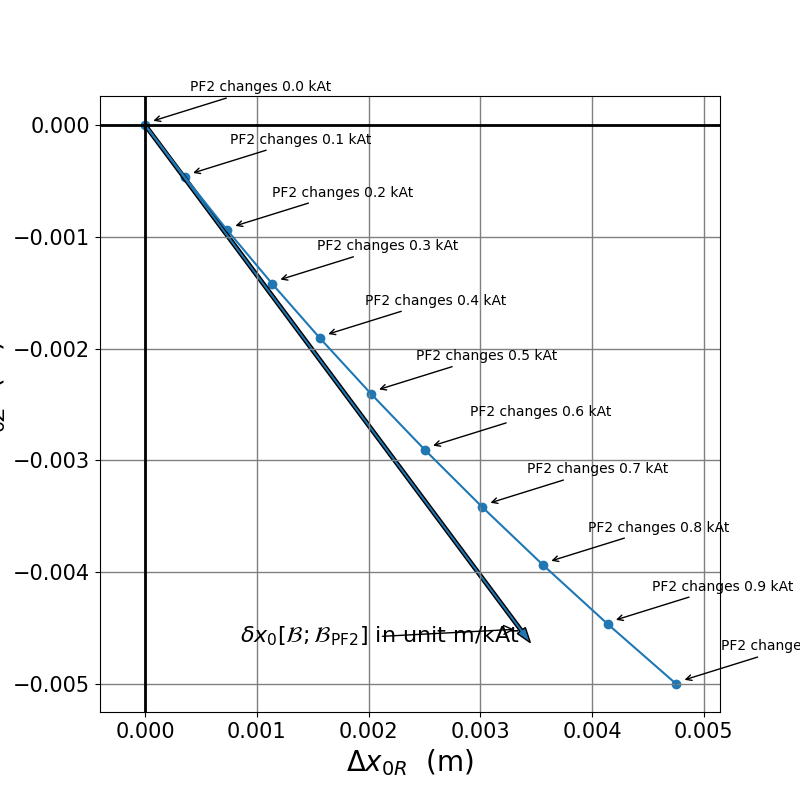

In [79]:
import matplotlib.pyplot as plt
%matplotlib widget
fig_shift_pert, ax_shift_pert = plt.subplots(1,1,figsize=(8,8))
for ax in [ax_shift_pert,]:
    ax.scatter(
        [shift_cycleRZ[0]-cycleRZ(which_phi)[0] for shift_cycleRZ in cycleRZ_under_pert],
        [shift_cycleRZ[1]-cycleRZ(which_phi)[1] for shift_cycleRZ in cycleRZ_under_pert],
        label = "Cycle shift under a given perturbation"
    )
    ax.plot(
        [shift_cycleRZ[0]-cycleRZ(which_phi)[0] for shift_cycleRZ in cycleRZ_under_pert],
        [shift_cycleRZ[1]-cycleRZ(which_phi)[1] for shift_cycleRZ in cycleRZ_under_pert],
    )
    
    ax.arrow(0,0, *Delta_x0_ivp.sol(which_phi), width=3e-5, length_includes_head=True)
    
#     # for phi=0.0
#     for i, I_coil_kAt in enumerate(np.linspace(0.0, 1.0, num=11) ):
#         ax.annotate(f"PF2 changes {I_coil_kAt:.1f} kAt", 
#             xy=cycleRZ_under_pert[i]-cycleRZ(which_phi) + [-0.00005, 0.00003], 
#             xytext=cycleRZ_under_pert[i]-cycleRZ(which_phi)+[-0.0024,0.0002], 
#             arrowprops=dict(arrowstyle='->') )
        
#     ax.annotate("$\delta x_{0} [\mathcal{B}; \mathcal{B}_{\mathrm{PF2}}]$ in unit m/kAt", 
#         xy=Delta_x0_ivp.sol(which_phi) + [0.00005, -0.00003], 
#         xytext=Delta_x0_ivp.sol(which_phi) + [0.0002, -0.0004], 
#         arrowprops=dict(arrowstyle='->'), fontsize=16 )
    
#     # for phi=2*np.pi
#     for i, I_coil_kAt in enumerate(np.linspace(0.0, 1.0, num=11) ):
#         ax.annotate(f"PF2 changes {I_coil_kAt:.1f} kAt", 
#             xy=cycleRZ_under_pert[i]-cycleRZ(which_phi) + [0.00005, -0.00003], 
#             xytext=cycleRZ_under_pert[i]-cycleRZ(which_phi)+[0.0001, -0.0004], 
#             arrowprops=dict(arrowstyle='->') )
        
#     ax.annotate("$\delta x_{0} [\mathcal{B}; \mathcal{B}_{\mathrm{PF2}}]$ in unit m/kAt", 
#         xy=Delta_x0_ivp.sol(which_phi) + [+0.00012, 0.00012], 
#         xytext=Delta_x0_ivp.sol(which_phi) + [+0.0002, 0.0008], 
#         arrowprops=dict(arrowstyle='->'), fontsize=16 )
    
    # for phi=4*np.pi
    for i, I_coil_kAt in enumerate(np.linspace(0.0, 1.0, num=11) ):
        ax.annotate(f"PF2 changes {I_coil_kAt:.1f} kAt", 
            xy=cycleRZ_under_pert[i]-cycleRZ(which_phi) + [0.00005, +0.00003], 
            xytext=cycleRZ_under_pert[i]-cycleRZ(which_phi)+[0.0004, +0.0003], 
            arrowprops=dict(arrowstyle='->') )
        
    ax.annotate("$\delta x_{0} [\mathcal{B}; \mathcal{B}_{\mathrm{PF2}}]$ in unit m/kAt", 
        xy=Delta_x0_ivp.sol(which_phi) + [-0.00012, 0.00012], 
        xytext=Delta_x0_ivp.sol(which_phi) + [-0.0026, -0.0000], 
        arrowprops=dict(arrowstyle='->'), fontsize=16 )
    
    # Customize grid appearance
    ax.grid(True, which='major', linestyle='-', linewidth=1, color='gray')  # Show grid on major tick coordinates
    ax.grid(True, which='minor', linestyle='--', linewidth=0.5, color='gray')  # Show grid on minor tick coordinates
    
    ax.axhline(0.0, color="black", linewidth=2.0)
    ax.axvline(0.0, color="black", linewidth=2.0)

    
    ax.set_xlabel("$\Delta x_{0R}$  (m)", fontsize=20)
    ax.set_ylabel("$\Delta x_{0Z}$  (m)", fontsize=20)
    for tick in ax.xaxis.get_major_ticks():
        tick.label.set_fontsize(15)
    for tick in ax.yaxis.get_major_ticks():
        tick.label.set_fontsize(15)
    ax.axis("equal")